## 1. Установка random seed и импорт библиотек

In [1]:
# Установка random seed и импорт необходимых библиотек
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
from nltk.corpus import stopwords
import nltk
from tqdm.notebook import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Устанавливаем random seed для воспроизводимости результатов
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Random seed установлен на значение:", RANDOM_SEED)

D:\setup\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Random seed установлен на значение: 42


## 2. Загрузка данных 

In [2]:
# загрузил данные с кэгл
df = pd.read_csv('lenta-ru-news.csv')

# Вывод информации о датасете
print("Размер датасета:", len(df))
print("Количество уникальных топиков:", df['topic'].nunique())
print("Уникальные топики:", df['topic'].unique())
print("\nПримеры записей:")
print(df.head())

Размер датасета: 800975
Количество уникальных топиков: 23
Уникальные топики: ['Библиотека' 'Россия' 'Мир' 'Экономика' 'Интернет и СМИ' 'Спорт'
 'Культура' 'Из жизни' 'Силовые структуры' 'Наука и техника' 'Бывший СССР'
 nan 'Дом' 'Сочи' 'ЧМ-2014' 'Путешествия' 'Ценности' 'Легпром' 'Бизнес'
 'МедНовости' 'Оружие' '69-я параллель' 'Культпросвет ' 'Крым']

Примеры записей:
                                           url  \
0   https://lenta.ru/news/1914/09/16/hungarnn/   
1  https://lenta.ru/news/1914/09/16/lermontov/   
2  https://lenta.ru/news/1914/09/17/nesteroff/   
3   https://lenta.ru/news/1914/09/17/bulldogn/   
4       https://lenta.ru/news/1914/09/18/zver/   

                                               title  \
0  1914. Русские войска вступили в пределы Венгрии     
1  1914. Празднование столетия М.Ю. Лермонтова от...   
2                           1914. Das ist Nesteroff!   
3                    1914. Бульдог-гонец под Льежем    
4           1914. Под Люблином пойман швабский 

## 3. Анализ датасета

Размер датасета: 800975
Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800975 entries, 0 to 800974
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     800975 non-null  object
 1   title   800975 non-null  object
 2   text    800970 non-null  object
 3   topic   738973 non-null  object
 4   tags    773756 non-null  object
 5   date    800975 non-null  object
dtypes: object(6)
memory usage: 36.7+ MB
None

Количество уникальных топиков: 23
5 наиболее частых топиков:
topic
Россия       160445
Мир          136621
Экономика     79528
Спорт         64413
Культура      53797
Name: count, dtype: int64


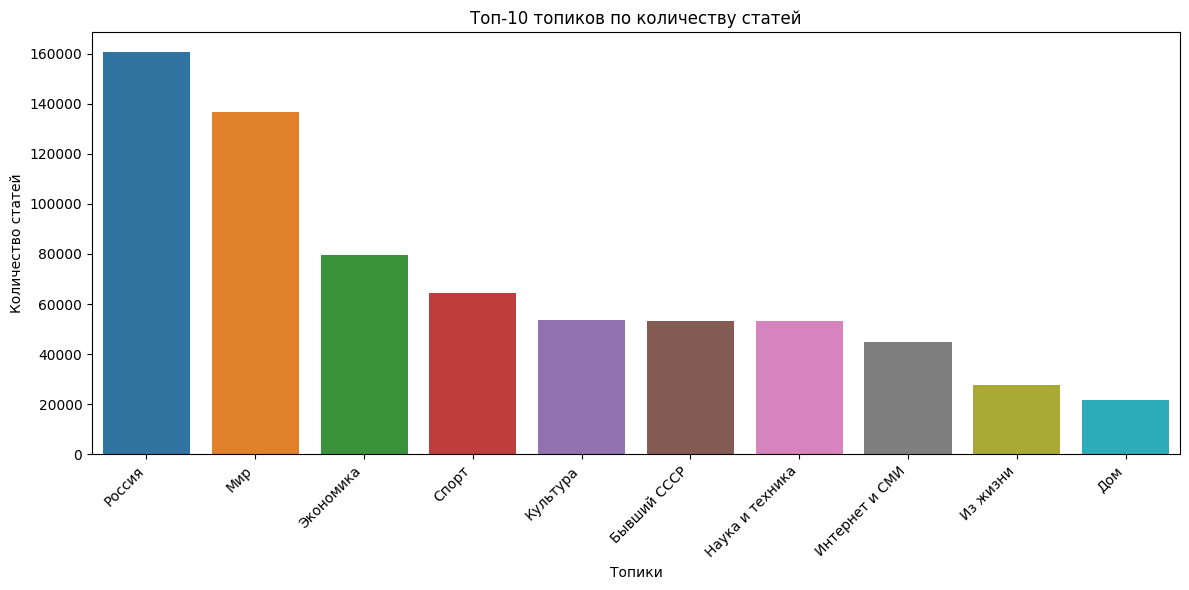

In [3]:
# Предполагаем, что у нас уже загружен датасет lenta-ru-news в DataFrame df
# Выведем основную информацию о датасете
print("Размер датасета:", len(df))
print("Информация о столбцах:")
print(df.info())

# Проверим количество уникальных топиков
print("\nКоличество уникальных топиков:", df['topic'].nunique())
print("5 наиболее частых топиков:")
print(df['topic'].value_counts().head())

# Отобразим распределение топиков
plt.figure(figsize=(12, 6))
top_topics = df['topic'].value_counts().head(10)
sns.barplot(x=top_topics.index, y=top_topics.values)
plt.title('Топ-10 топиков по количеству статей')
plt.ylabel('Количество статей')
plt.xlabel('Топики')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Базовая предобработка текста

In [4]:
# 2. Предобработка данных
# Загружаем необходимые ресурсы NLTK
nltk.download('stopwords')

# Получаем стоп-слова для русского языка
russian_stopwords = stopwords.words('russian')

# Для ускорения обработки ограничимся небольшой выборкой
reduced_sample_size = 5000  # Используем очень малую выборку для демонстрации
if len(df) > reduced_sample_size:
    df_sample = df.sample(reduced_sample_size, random_state=RANDOM_SEED)
    print(f"Выборка уменьшена до {reduced_sample_size} записей для демонстрации")
else:
    df_sample = df.copy()

print(f"Работаем с выборкой размером {len(df_sample)} записей")

Выборка уменьшена до 5000 записей для демонстрации
Работаем с выборкой размером 5000 записей


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 5. Функция предобработки текста

In [7]:
# Функция для предобработки текста (оптимизированная, без стемминга)
def preprocess_text_optimized(text):
    if not isinstance(text, str) or pd.isna(text):
        return ""  # Возвращаем пустую строку для NaN и не-строк
    
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Удаление специальных символов и цифр
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Токенизация и фильтрация стоп-слов
    tokens = [token for token in text.split() if token not in russian_stopwords]
    
    # Объединение обратно в текст
    return ' '.join(tokens)

# Отслеживание прогресса
tqdm.pandas()

# Применение предобработки
print("Начинаем предобработку текстов...")
df_sample['processed_title'] = df_sample['title'].progress_apply(preprocess_text_optimized)
df_sample['processed_text'] = df_sample['text'].progress_apply(preprocess_text_optimized)
df_sample['processed_combined'] = df_sample['processed_title'] + ' ' + df_sample['processed_text']

# Проверка на NaN значения
print("\nПроверка на пропущенные значения после предобработки:")
print(df_sample[['processed_title', 'processed_text', 'processed_combined']].isna().sum())

# Заполняем NaN значения пустыми строками, если остались
df_sample['processed_title'] = df_sample['processed_title'].fillna('')
df_sample['processed_text'] = df_sample['processed_text'].fillna('')
df_sample['processed_combined'] = df_sample['processed_combined'].fillna('')

# Проверка на NaN в целевой переменной
print("\nПроверка на пропущенные значения в топиках:")
print(df_sample['topic'].isna().sum())

# Удаляем строки с NaN в целевой переменной
if df_sample['topic'].isna().sum() > 0:
    print("Удаляем строки с пропущенными значениями в целевой переменной")
    df_sample = df_sample.dropna(subset=['topic'])
    print(f"Осталось {len(df_sample)} строк после удаления")

print("Предобработка завершена.")
print("\nПримеры обработанных текстов:")
for i in range(min(3, len(df_sample))):
    print(f"Оригинальный заголовок: {df_sample['title'].iloc[i]}")
    print(f"Обработанный заголовок: {df_sample['processed_title'].iloc[i]}")
    print(f"Топик: {df_sample['topic'].iloc[i]}")
    print("---")

# Описание пайплайна предобработки
print("\nОписание пайплайна предобработки:")
print("1. Приведение текста к нижнему регистру")
print("2. Удаление специальных символов и цифр")
print("3. Токенизация текста")
print("4. Удаление стоп-слов для русского языка")
print("5. Заполнение пропущенных значений")
print("6. Объединение заголовка и текста статьи")
print("\nПримечание: стемминг был исключен для ускорения обработки.")

Начинаем предобработку текстов...


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]


Проверка на пропущенные значения после предобработки:
processed_title       0
processed_text        0
processed_combined    0
dtype: int64

Проверка на пропущенные значения в топиках:
404
Удаляем строки с пропущенными значениями в целевой переменной
Осталось 4596 строк после удаления
Предобработка завершена.

Примеры обработанных текстов:
Оригинальный заголовок: Жена Оззи Осборна выиграла суд против британского таблоида
Обработанный заголовок: жена оззи осборна выиграла суд против британского таблоида
Топик: Культура
---
Оригинальный заголовок: В Осло вручили международную премию Абеля по математике
Обработанный заголовок: осло вручили международную премию абеля математике
Топик: Наука и техника
---
Оригинальный заголовок: Сбивший полицейского российский дипломат покинул Нью-Йорк
Обработанный заголовок: сбивший полицейского российский дипломат покинул ньюйорк
Топик: Мир
---

Описание пайплайна предобработки:
1. Приведение текста к нижнему регистру
2. Удаление специальных символов и ци

## 6. Разделение данных на выборки

In [8]:
# Убедимся, что у нас нет пустых значений в топиках (на всякий случай)
df_sample = df_sample.dropna(subset=['topic'])

# Проверяем, сколько у нас образцов для каждого класса
class_counts = df_sample['topic'].value_counts()
print("Количество образцов для каждого класса:")
print(class_counts.head(10))  # Показываем топ-10 классов

# Находим классы с малым количеством образцов (меньше 3)
small_classes = class_counts[class_counts < 3].index.tolist()
if small_classes:
    print(f"\nНайдены классы с малым количеством образцов: {small_classes}")
    print("Удаляем эти классы для возможности стратификации")
    df_sample = df_sample[~df_sample['topic'].isin(small_classes)]
    print(f"Осталось {len(df_sample)} строк после удаления редких классов")

# Разделение данных на обучающую, валидационную и тестовую выборки
# Сначала отделим тестовую часть (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    df_sample['processed_combined'], 
    df_sample['topic'], 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=df_sample['topic']
)

# Затем разделим оставшуюся часть на обучающую (60% от всего) и валидационную (20% от всего)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2 (от всего)
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f"Размер обучающей выборки: {len(X_train)} (60%)")
print(f"Размер валидационной выборки: {len(X_val)} (20%)")
print(f"Размер тестовой выборки: {len(X_test)} (20%)")

# Проверим стратификацию
print("\nРаспределение классов в выборках:")
print("Обучающая выборка:", y_train.value_counts(normalize=True).head())
print("Валидационная выборка:", y_val.value_counts(normalize=True).head())
print("Тестовая выборка:", y_test.value_counts(normalize=True).head())

Количество образцов для каждого класса:
topic
Россия             984
Мир                792
Экономика          443
Спорт              440
Бывший СССР        352
Наука и техника    346
Культура           335
Интернет и СМИ     289
Из жизни           177
Дом                141
Name: count, dtype: int64

Найдены классы с малым количеством образцов: ['Легпром']
Удаляем эти классы для возможности стратификации
Осталось 4594 строк после удаления редких классов
Размер обучающей выборки: 2756 (60%)
Размер валидационной выборки: 919 (20%)
Размер тестовой выборки: 919 (20%)

Распределение классов в выборках:
Обучающая выборка: topic
Россия         0.214078
Мир            0.172351
Экономика      0.096154
Спорт          0.095791
Бывший СССР    0.076923
Name: proportion, dtype: float64
Валидационная выборка: topic
Россия         0.214363
Мир            0.173014
Экономика      0.096844
Спорт          0.095756
Бывший СССР    0.076170
Name: proportion, dtype: float64
Тестовая выборка: topic
Россия    

## 7. Оценка dummy-базового качества

In [9]:
# 3. Замер базового качества с dummy-бейзлайном
# Создаем и обучаем dummy-классификатор (стратегия - самый частый класс)
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy_clf.fit(X_train, y_train)

# Оценка на валидационной выборке
dummy_pred = dummy_clf.predict(X_val)
dummy_accuracy = accuracy_score(y_val, dummy_pred)

print(f"Базовое качество (dummy classifier, стратегия 'most_frequent'): {dummy_accuracy:.4f}")
print("\nОтчет о классификации для dummy-модели:")
print(classification_report(y_val, dummy_pred, zero_division=0))

Базовое качество (dummy classifier, стратегия 'most_frequent'): 0.2144

Отчет о классификации для dummy-модели:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00         2
           Бизнес       0.00      0.00      0.00        13
      Бывший СССР       0.00      0.00      0.00        70
              Дом       0.00      0.00      0.00        28
         Из жизни       0.00      0.00      0.00        35
   Интернет и СМИ       0.00      0.00      0.00        58
             Крым       0.00      0.00      0.00         1
         Культура       0.00      0.00      0.00        67
              Мир       0.00      0.00      0.00       159
  Наука и техника       0.00      0.00      0.00        69
      Путешествия       0.00      0.00      0.00         8
           Россия       0.21      1.00      0.35       197
Силовые структуры       0.00      0.00      0.00        23
            Спорт       0.00      0.00      0.00        88
  

## 8 Обучение модели с CountVectorizer

In [10]:
# 4. Обучение модели с векторизацией CountVectorizer
# Создание векторизатора CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000)  # Уменьшаем количество признаков для ускорения

# Векторизация данных
X_train_count = count_vectorizer.fit_transform(X_train)
X_val_count = count_vectorizer.transform(X_val)

# Создание и обучение модели LogisticRegression
lr_count = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=100,  # Уменьшаем количество итераций для ускорения
    solver='saga',
    n_jobs=-1
)

print("Обучение модели с CountVectorizer...")
lr_count.fit(X_train_count, y_train)

# Оценка на валидационной выборке
lr_count_pred = lr_count.predict(X_val_count)
lr_count_accuracy = accuracy_score(y_val, lr_count_pred)

print(f"Точность модели с CountVectorizer: {lr_count_accuracy:.4f}")
print("\nОтчет о классификации для модели с CountVectorizer:")
print(classification_report(y_val, lr_count_pred, zero_division=0))

Обучение модели с CountVectorizer...
Точность модели с CountVectorizer: 0.6899

Отчет о классификации для модели с CountVectorizer:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00         2
           Бизнес       1.00      0.08      0.14        13
      Бывший СССР       0.76      0.54      0.63        70
              Дом       0.91      0.71      0.80        28
         Из жизни       0.60      0.34      0.44        35
   Интернет и СМИ       0.67      0.45      0.54        58
             Крым       0.00      0.00      0.00         1
         Культура       0.76      0.79      0.77        67
              Мир       0.62      0.77      0.68       159
  Наука и техника       0.79      0.72      0.76        69
      Путешествия       0.00      0.00      0.00         8
           Россия       0.58      0.80      0.67       197
Силовые структуры       0.50      0.04      0.08        23
            Спорт       0.94      0.97   

## 9 Обучение модели с TfidfVectorizer

In [11]:
# Обучение модели с векторизацией TfidfVectorizer
# Создание векторизатора TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Уменьшаем количество признаков для ускорения

# Векторизация данных
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Создание и обучение модели LogisticRegression
lr_tfidf = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=100,  # Уменьшаем количество итераций для ускорения
    solver='saga',
    n_jobs=-1
)

print("Обучение модели с TfidfVectorizer...")
lr_tfidf.fit(X_train_tfidf, y_train)

# Оценка на валидационной выборке
lr_tfidf_pred = lr_tfidf.predict(X_val_tfidf)
lr_tfidf_accuracy = accuracy_score(y_val, lr_tfidf_pred)

print(f"Точность модели с TfidfVectorizer: {lr_tfidf_accuracy:.4f}")
print("\nОтчет о классификации для модели с TfidfVectorizer:")
print(classification_report(y_val, lr_tfidf_pred, zero_division=0))

# Сравнение моделей
print("\nСравнение моделей:")
print(f"Baseline (dummy): {dummy_accuracy:.4f}")
print(f"LogisticRegression с CountVectorizer: {lr_count_accuracy:.4f}")
print(f"LogisticRegression с TfidfVectorizer: {lr_tfidf_accuracy:.4f}")

# Определение лучшей модели
best_model_name = "TfidfVectorizer" if lr_tfidf_accuracy > lr_count_accuracy else "CountVectorizer"
print(f"\nНа данном этапе лучшая модель: LogisticRegression с {best_model_name}")

Обучение модели с TfidfVectorizer...
Точность модели с TfidfVectorizer: 0.6649

Отчет о классификации для модели с TfidfVectorizer:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00         2
           Бизнес       0.00      0.00      0.00        13
      Бывший СССР       0.77      0.43      0.55        70
              Дом       1.00      0.50      0.67        28
         Из жизни       0.75      0.09      0.15        35
   Интернет и СМИ       0.75      0.36      0.49        58
             Крым       0.00      0.00      0.00         1
         Культура       0.82      0.70      0.76        67
              Мир       0.59      0.83      0.69       159
  Наука и техника       0.83      0.71      0.77        69
      Путешествия       0.00      0.00      0.00         8
           Россия       0.52      0.85      0.65       197
Силовые структуры       0.00      0.00      0.00        23
            Спорт       0.98      0.97   

## 10 Подбор гиперпараметров для лучшей модели

In [12]:
# 5. Улучшение качества путем подбора оптимальных гиперпараметров
# Выбираем лучшую модель и векторизатор
if lr_tfidf_accuracy > lr_count_accuracy:
    best_vectorizer = tfidf_vectorizer
    X_train_vec = X_train_tfidf
    X_val_vec = X_val_tfidf
    best_model_name = "TfidfVectorizer"
else:
    best_vectorizer = count_vectorizer
    X_train_vec = X_train_count
    X_val_vec = X_val_count
    best_model_name = "CountVectorizer"

print(f"Подбор гиперпараметров для LogisticRegression с {best_model_name}...")

# Определение упрощенной сетки параметров для Grid Search
param_grid = {
    'C': [0.1, 1.0],  # Уменьшаем количество вариантов для ускорения
    'penalty': ['l2'],  # Используем только одну опцию для ускорения
    'solver': ['saga'],
    'max_iter': [100]  # Уменьшаем количество итераций для ускорения
}

# Создание объекта Grid Search с упрощенным CV
grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid,
    cv=2,  # Уменьшаем количество фолдов для ускорения
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучение Grid Search
grid_search.fit(X_train_vec, y_train)

# Вывод лучших параметров
print("\nЛучшие параметры:")
print(grid_search.best_params_)

# Оценка лучшей модели на валидационной выборке
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_val_vec)
best_accuracy = accuracy_score(y_val, best_pred)

print(f"\nТочность лучшей модели после подбора гиперпараметров: {best_accuracy:.4f}")
print("\nОтчет о классификации для лучшей модели:")
print(classification_report(y_val, best_pred, zero_division=0))

# Сравнение с предыдущими моделями
print("\nСравнение всех моделей:")
print(f"Baseline (dummy): {dummy_accuracy:.4f}")
print(f"LogisticRegression с CountVectorizer: {lr_count_accuracy:.4f}")
print(f"LogisticRegression с TfidfVectorizer: {lr_tfidf_accuracy:.4f}")
print(f"Лучшая модель после подбора гиперпараметров: {best_accuracy:.4f}")

Подбор гиперпараметров для LogisticRegression с CountVectorizer...
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Лучшие параметры:
{'C': 1.0, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}

Точность лучшей модели после подбора гиперпараметров: 0.6899

Отчет о классификации для лучшей модели:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00         2
           Бизнес       1.00      0.08      0.14        13
      Бывший СССР       0.76      0.54      0.63        70
              Дом       0.91      0.71      0.80        28
         Из жизни       0.60      0.34      0.44        35
   Интернет и СМИ       0.67      0.45      0.54        58
             Крым       0.00      0.00      0.00         1
         Культура       0.76      0.79      0.77        67
              Мир       0.62      0.77      0.68       159
  Наука и техника       0.79      0.72      0.76        69
      Путешествия       0.00      0.00

## 11 Оценка на тестовой выборке

Окончательная точность на тестовой выборке: 0.7193

Отчет о классификации на тестовой выборке:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00         2
           Бизнес       0.00      0.00      0.00        13
      Бывший СССР       0.75      0.59      0.66        70
              Дом       0.94      0.54      0.68        28
         Из жизни       0.62      0.43      0.51        35
   Интернет и СМИ       0.68      0.47      0.55        58
             Крым       0.00      0.00      0.00         1
         Культура       0.81      0.84      0.82        67
              Мир       0.69      0.84      0.76       158
  Наука и техника       0.71      0.74      0.72        69
      Путешествия       0.00      0.00      0.00         8
           Россия       0.63      0.83      0.72       197
Силовые структуры       0.60      0.13      0.21        23
            Спорт       0.99      0.89      0.93        88
         Ценности  

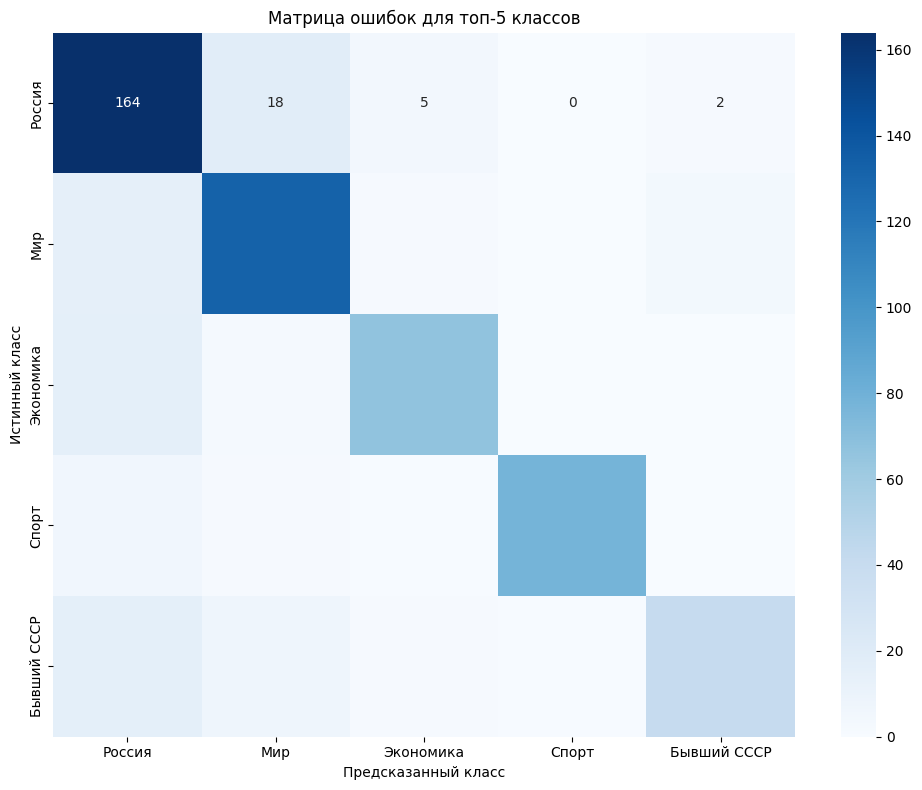


Итоговое резюме пайплайна классификации:
1. Загрузка данных lenta-ru-news: полный размер 800975 записей
2. Использование выборки размером 4594 для демонстрации
3. Предобработка текстов: нормализация, очистка, удаление стоп-слов (без стемминга для ускорения)
4. Базовое качество (dummy classifier): 0.2144
5. Лучшая векторизация: CountVectorizer
6. Лучшие гиперпараметры: {'C': 1.0, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
7. Итоговое качество на тестовой выборке: 0.7193


In [13]:
# 6. Оценка качества лучшего пайплайна на отложенной выборке
# Векторизация тестовой выборки
X_test_vec = best_vectorizer.transform(X_test)

# Предсказание на тестовой выборке
final_pred = best_model.predict(X_test_vec)
final_accuracy = accuracy_score(y_test, final_pred)

print(f"Окончательная точность на тестовой выборке: {final_accuracy:.4f}")
print("\nОтчет о классификации на тестовой выборке:")
print(classification_report(y_test, final_pred, zero_division=0))

# Матрица ошибок для топ-классов
# Определим количество топ-классов на основе размера выборки
# Для небольшой выборки используем меньше классов
top_n = min(5, y_test.nunique())
top_classes = y_test.value_counts().nlargest(top_n).index.tolist()

mask_test = y_test.isin(top_classes)
y_test_top = y_test[mask_test]
pred_test_top = np.array(final_pred)[mask_test]

cm = confusion_matrix(y_test_top, pred_test_top, labels=top_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=top_classes, yticklabels=top_classes)
plt.title(f'Матрица ошибок для топ-{top_n} классов')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Итоговое резюме
print("\nИтоговое резюме пайплайна классификации:")
print(f"1. Загрузка данных lenta-ru-news: полный размер {len(df)} записей")
print(f"2. Использование выборки размером {len(df_sample)} для демонстрации")
print(f"3. Предобработка текстов: нормализация, очистка, удаление стоп-слов (без стемминга для ускорения)")
print(f"4. Базовое качество (dummy classifier): {dummy_accuracy:.4f}")
print(f"5. Лучшая векторизация: {best_model_name}")
print(f"6. Лучшие гиперпараметры: {grid_search.best_params_}")
print(f"7. Итоговое качество на тестовой выборке: {final_accuracy:.4f}")